In [1]:
# Compare shared diagonal Gaussian HMMs using brain data only.
from pathlib import Path
import json
import os
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from joblib import Parallel, delayed, parallel_config
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

SEED = 28
N_COMPONENTS = 24
K_VALUES = range(3, 16)
N_FOLDS = 5
N_INITIALIZATIONS = 10
N_JOBS = min(8, os.cpu_count() or 1)

cwd = Path.cwd()
ROOT = cwd if (cwd / "data" / "raw").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
assert RAW.exists(), f"Could not find data/raw from {cwd}"
sns.set_theme(style="ticks", context="notebook")

In [2]:
def session_number(path):
    return int(re.search(r"ses-(\d+)", path.name).group(1))


def contiguous_runs(valid):
    changes = np.diff(np.r_[False, valid, False].astype(int))
    return list(zip(np.flatnonzero(changes == 1), np.flatnonzero(changes == -1)))


def standardize_session(x):
    valid = ~np.isnan(x).any(axis=1)
    observed = x[valid]
    z = np.full(x.shape, np.nan, dtype=float)
    z[valid] = (observed - observed.mean(axis=0)) / observed.std(axis=0, ddof=1)
    return z, valid


def session_sequences(session):
    return [session["z"][start:stop] for start, stop in contiguous_runs(session["valid"])]


def combine(sequences):
    return np.vstack(sequences), [len(sequence) for sequence in sequences]

In [3]:
files = sorted(RAW.glob("*.npy"), key=session_number)[:30]
sessions = []
for path in files:
    x = np.load(path).T
    z, valid = standardize_session(x)
    sessions.append({"session": session_number(path), "z": z, "valid": valid})

assert len(sessions) == 30
assert all(item["z"].shape == (820, 100) for item in sessions)
[(item["session"], len(contiguous_runs(item["valid"]))) for item in sessions[:5]]

[(1, 1), (2, 1), (3, 2), (4, 1), (5, 2)]

In [4]:
# Split entire sessions, then fit PCA only on each fold's training sessions.
fold_rows = []
fold_data = {}
splitter = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (train_idx, test_idx) in enumerate(splitter.split(sessions), start=1):
    train_sequences = [sequence for i in train_idx for sequence in session_sequences(sessions[i])]
    test_sequences = [sequence for i in test_idx for sequence in session_sequences(sessions[i])]
    pca = PCA(n_components=N_COMPONENTS, svd_solver="full").fit(np.vstack(train_sequences))
    train_pca = [pca.transform(sequence) for sequence in train_sequences]
    test_pca = [pca.transform(sequence) for sequence in test_sequences]
    train_x, train_lengths = combine(train_pca)
    test_x, test_lengths = combine(test_pca)
    fold_data[fold] = {
        "train_x": train_x, "train_lengths": train_lengths,
        "test_x": test_x, "test_lengths": test_lengths,
    }
    fold_rows.append({
        "fold": fold, "split_seed": SEED,
        "train_sessions": json.dumps([sessions[i]["session"] for i in train_idx]),
        "test_sessions": json.dumps([sessions[i]["session"] for i in test_idx]),
        "n_train_trs": len(train_x), "n_test_trs": len(test_x),
        "n_train_sequences": len(train_lengths), "n_test_sequences": len(test_lengths),
        "pca_variance_retained": pca.explained_variance_ratio_.sum(),
    })

folds = pd.DataFrame(fold_rows)
folds.to_csv(TABLES / "hmm_cv_folds.csv", index=False)
folds

,fold,split_seed,train_sessions,test_sessions,n_train_trs,n_test_trs,n_train_sequences,n_test_sequences,pca_variance_retained
0,1,28,"[1, 2, 3, 4, 6, 7, 8, 9, 12, 13, 15, 16, 17, 1...","[5, 10, 11, 14, 22, 24]",19591,4879,49,18,0.805740
1,2,28,"[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, ...","[7, 8, 16, 18, 19, 30]",19564,4906,57,10,0.805278
2,3,28,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 13, 14, 16, 18, ...","[3, 9, 12, 15, 17, 28]",19582,4888,52,15,0.803407
3,4,28,"[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 1...","[4, 13, 20, 25, 27, 29]",19577,4893,54,13,0.804335
4,5,28,"[3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...","[1, 2, 6, 21, 23, 26]",19566,4904,56,11,0.801853


In [5]:
def fit_one(k, fold, initialization, seed):
    data = fold_data[fold]
    started = time.perf_counter()
    result = {"k": k, "fold": fold, "initialization": initialization, "seed": seed}
    try:
        model = GaussianHMM(
            n_components=k, covariance_type="diag", n_iter=200, tol=1e-3,
            min_covar=1e-3, random_state=seed, implementation="scaling",
        )
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            warnings.simplefilter("ignore", DeprecationWarning)
            model.fit(data["train_x"], data["train_lengths"])
            train_ll, train_posterior = model.score_samples(data["train_x"], data["train_lengths"])
            test_ll, test_posterior = model.score_samples(data["test_x"], data["test_lengths"])
        train_occupancy = train_posterior.mean(axis=0)
        test_occupancy = test_posterior.mean(axis=0)
        result.update({
            "status": "ok", "converged": bool(model.monitor_.converged),
            "n_iterations": int(model.monitor_.iter),
            "train_log_likelihood": train_ll, "test_log_likelihood": test_ll,
            "train_log_likelihood_per_tr": train_ll / len(data["train_x"]),
            "test_log_likelihood_per_tr": test_ll / len(data["test_x"]),
            "train_occupancies": json.dumps(train_occupancy.tolist()),
            "test_occupancies": json.dumps(test_occupancy.tolist()),
            "min_train_occupancy": train_occupancy.min(),
            "min_test_occupancy": test_occupancy.min(),
            "warning_count": len({str(item.message) for item in caught}),
            "warnings": " | ".join(sorted({str(item.message) for item in caught})),
            "error": "",
        })
    except Exception as error:
        result.update({"status": "error", "converged": False, "error": repr(error)})
    result["elapsed_seconds"] = time.perf_counter() - started
    return result

In [6]:
# Every seed is deterministic and uniquely identifies K, fold, and initialization.
jobs = [
    (k, fold, initialization, SEED * 1_000_000 + k * 10_000 + fold * 100 + initialization)
    for k in K_VALUES
    for fold in range(1, N_FOLDS + 1)
    for initialization in range(1, N_INITIALIZATIONS + 1)
]
started = time.perf_counter()
with parallel_config(backend="loky", inner_max_num_threads=1):
    records = Parallel(n_jobs=N_JOBS, verbose=5)(delayed(fit_one)(*job) for job in jobs)
results = pd.DataFrame(records).sort_values(["k", "fold", "initialization"]).reset_index(drop=True)
results = results.merge(folds, on="fold", validate="many_to_one")
results.to_csv(TABLES / "hmm_model_selection_full.csv", index=False)
print(f"Completed {len(results)} fits in {(time.perf_counter() - started) / 60:.1f} minutes")
results.groupby(["status", "converged"], dropna=False).size().rename("fits")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    3.3s


[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   14.2s


[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   48.8s


[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:  2.4min


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  5.9min


[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed: 12.4min


[Parallel(n_jobs=8)]: Done 650 out of 650 | elapsed: 13.0min finished


Completed 650 fits in 13.2 minutes


status  converged
ok      True         650
Name: fits, dtype: int64

In [7]:
# Within each K and fold, evaluate the initialization with the best training fit.
valid_results = results.query("status == 'ok' and converged").copy()
best_index = valid_results.groupby(["k", "fold"])["train_log_likelihood_per_tr"].idxmax()
selected = valid_results.loc[best_index].sort_values(["k", "fold"]).reset_index(drop=True)
selected.to_csv(TABLES / "hmm_model_selection_selected_initializations.csv", index=False)

summary = selected.groupby("k").agg(
    mean_test_log_likelihood_per_tr=("test_log_likelihood_per_tr", "mean"),
    sd_test_log_likelihood_per_tr=("test_log_likelihood_per_tr", "std"),
    mean_min_test_occupancy=("min_test_occupancy", "mean"),
    minimum_test_occupancy=("min_test_occupancy", "min"),
    converged_folds=("fold", "nunique"),
).reset_index()
summary.to_csv(TABLES / "hmm_model_selection_summary.csv", index=False)
summary.round(4)

,k,mean_test_log_likelihood_per_tr,sd_test_log_likelihood_per_tr,mean_min_test_occupancy,minimum_test_occupancy,converged_folds
0,3,-40.5182,0.1810,0.1656,0.1378,5
1,4,-40.3291,0.1666,0.1311,0.1083,5
2,5,-40.1378,0.1899,0.1006,0.0965,5
3,6,-40.0356,0.1738,0.0886,0.0784,5
4,7,-39.9021,0.1890,0.0841,0.0774,5
5,8,-39.8150,0.1967,0.0607,0.0239,5
6,9,-39.7512,0.2051,0.0433,0.0238,5
7,10,-39.6421,0.1974,0.0417,0.0239,5
8,11,-39.6015,0.2367,0.0267,0.0240,5
9,12,-39.4800,0.1911,0.0283,0.0239,5


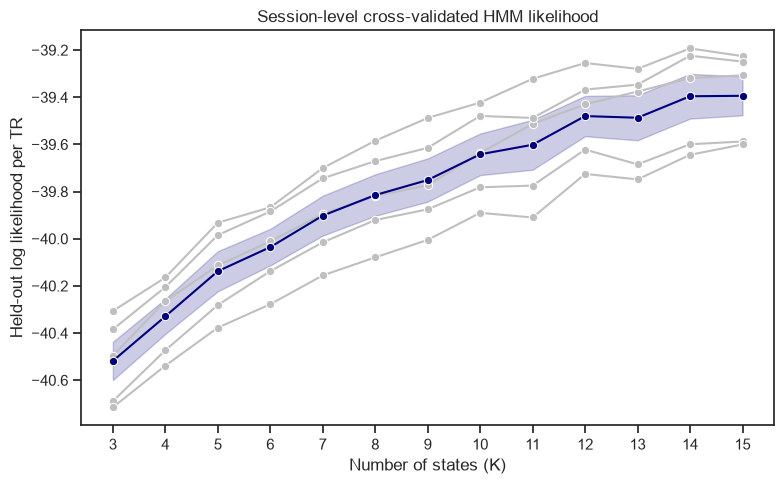

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=selected, x="k", y="test_log_likelihood_per_tr", units="fold", estimator=None, color="0.75", marker="o", ax=ax)
sns.lineplot(data=selected, x="k", y="test_log_likelihood_per_tr", color="navy", marker="o", errorbar=("se", 1), ax=ax)
ax.set(title="Session-level cross-validated HMM likelihood", xlabel="Number of states (K)", ylabel="Held-out log likelihood per TR", xticks=list(K_VALUES))
fig.tight_layout()
fig.savefig(FIGURES / "hmm_cv_heldout_likelihood.png", dpi=180, bbox_inches="tight")

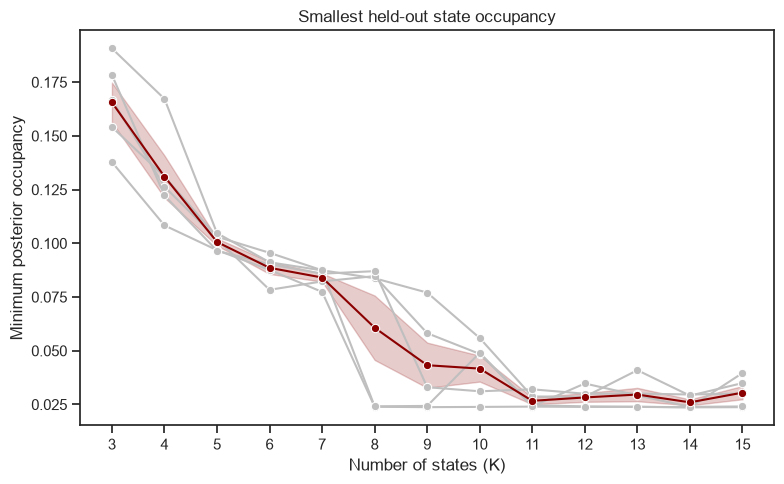

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=selected, x="k", y="min_test_occupancy", units="fold", estimator=None, color="0.75", marker="o", ax=ax)
sns.lineplot(data=selected, x="k", y="min_test_occupancy", color="darkred", marker="o", errorbar=("se", 1), ax=ax)
ax.set(title="Smallest held-out state occupancy", xlabel="Number of states (K)", ylabel="Minimum posterior occupancy", xticks=list(K_VALUES))
fig.tight_layout()
fig.savefig(FIGURES / "hmm_cv_minimum_state_occupancy.png", dpi=180, bbox_inches="tight")

In [10]:
diagnostics = pd.Series({
    "fits requested": len(jobs),
    "fits completed": results["status"].eq("ok").sum(),
    "fits converged": results["converged"].fillna(False).sum(),
    "fold-K combinations represented": selected.groupby(["k", "fold"]).ngroups,
    "final K selected": "No; inspect likelihood, occupancy, and stability diagnostics together",
}, name="model-selection diagnostics")
diagnostics

fits requested                                                                   650
fits completed                                                                   650
fits converged                                                                   650
fold-K combinations represented                                                   65
final K selected                   No; inspect likelihood, occupancy, and stabili...
Name: model-selection diagnostics, dtype: object